# UE24CS352A: Machine Learning
## Lab 5: Linear vs. Logistic Regression and Threshold Tuning

**Name:** Aditya TJ
**SRN:** PES1UG24CS031

**Objective:** Implement and compare linear regression and logistic regression for binary classification. Construct a robust machine learning pipeline and evaluate the impact of classification thresholds on model performance.

## Step 1: Import Libraries and Setup
Import necessary modules for data manipulation, modeling, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

# Bypass SSL certificate verification for dataset downloads
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Step 2: Generate 1D Toy Dataset & Inject Outlier
Create a synthetic 1D dataset representing "Hours Studied" versus a binary "Pass/Fail" outcome. An extreme outlier is intentionally included to highlight a core vulnerability in linear models.

In [2]:
np.random.seed(42)
X_toy = np.sort(np.random.uniform(0, 10, 20)).reshape(-1, 1)
y_toy = (X_toy[:, 0] > 5).astype(int)

# Inject an extreme outlier
X_toy = np.vstack([X_toy, [[50]]])
y_toy = np.append(y_toy, [1])

print("Toy dataset generated with shape:", X_toy.shape)

Toy dataset generated with shape: (21, 1)


## Step 3: Fit Linear Regression on Toy Dataset
Train a standard linear regression model on the classification data.

In [3]:
# Initialize Linear Regression
linear_model = LinearRegression()

# Fit the model
linear_model.fit(X_toy, y_toy)

# Generate predictions
y_lin_pred = linear_model.predict(X_toy)

print("Linear Regression Predictions:")
print(y_lin_pred)

print("\nMinimum prediction:", y_lin_pred.min())
print("Maximum prediction:", y_lin_pred.max())

Linear Regression Predictions:
[0.32253473 0.33135291 0.35437734 0.35438302 0.36045155 0.36082299
 0.36762717 0.38617871 0.38923883 0.40576987 0.41926904 0.44109429
 0.45847288 0.45905055 0.48420237 0.48982765 0.51344886 0.52138153
 0.54126127 0.54577524 1.4934792 ]

Minimum prediction: 0.32253472590265747
Maximum prediction: 1.493479196698211


## Step 4: Visualize Linear Regression Limitations
Plot the original data points and the linear regression line. Observe how the outlier pulls the line, causing standard data points to be misclassified when using a 0.5 boundary. Also note that predictions fall outside the [0, 1] probability range.

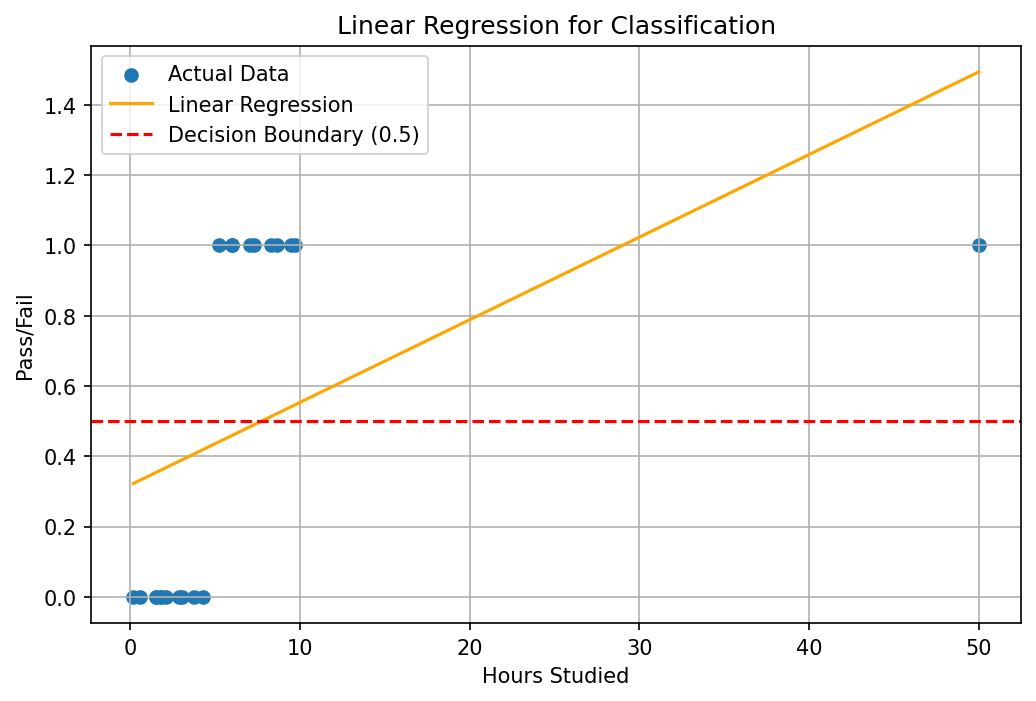

In [4]:
plt.figure(figsize=(8, 5))

# Plot original data points
plt.scatter(X_toy, y_toy, label='Actual Data')

# Plot linear regression line
plt.plot(X_toy, y_lin_pred, label='Linear Regression', color='orange')

# Decision boundary
plt.axhline(y=0.5, linestyle='--', color='red', label='Decision Boundary (0.5)')

plt.xlabel('Hours Studied')
plt.ylabel('Pass/Fail')
plt.title('Linear Regression for Classification')
plt.legend()
plt.grid(True)

plt.show()

## Step 5: Fit Logistic Regression on Toy Dataset
Train a logistic regression model on the exact same dataset to compare resilience against outliers.

In [5]:
# Initialize Logistic Regression
logistic_model = LogisticRegression(random_state=42)

# Fit the model
logistic_model.fit(X_toy, y_toy)

# Generate a dense range of X values
X_smooth = np.linspace(0, 50, 300).reshape(-1, 1)

# Probability of class 1
y_log_prob = logistic_model.predict_proba(X_smooth)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Step 6: Visualize Logistic Regression Resilience
Plot the logistic regression sigmoid curve. Observe how it bounds predictions between 0 and 1, maintaining an accurate decision boundary despite the outlier.

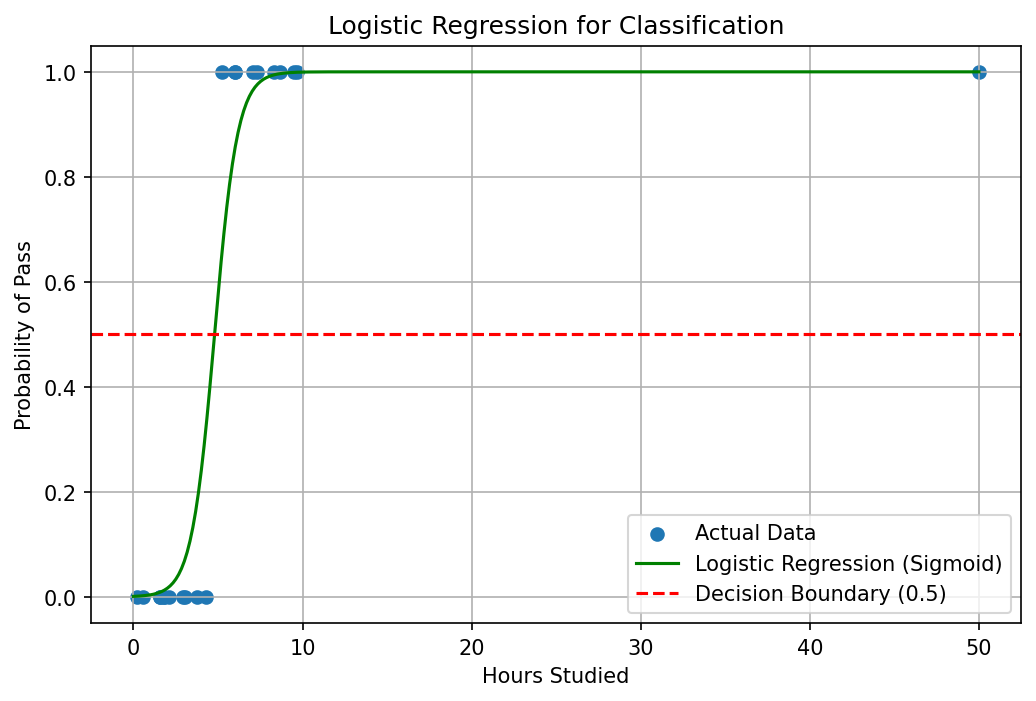

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(X_toy, y_toy, label='Actual Data')
plt.plot(X_smooth, y_log_prob, label='Logistic Regression (Sigmoid)', color='green')
plt.axhline(y=0.5, linestyle='--', color='red', label='Decision Boundary (0.5)')

plt.xlabel('Hours Studied')
plt.ylabel('Probability of Pass')
plt.title('Logistic Regression for Classification')
plt.legend()
plt.grid(True)

plt.show()

## Step 7: Load Real-World Dataset
Load the Wine Quality dataset and create a binary target variable to evaluate the full pipeline.

In [7]:
def load_wine_quality():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    data = pd.read_csv(url, sep=';')

    data['good_quality'] = (data['quality'] > 5).astype(int)

    X = data.drop(['quality', 'good_quality'], axis=1)
    y = data['good_quality']

    return train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

X_train, X_test, y_train, y_test = load_wine_quality()

print("Training data shape:", X_train.shape)

Training data shape: (1119, 11)


## Step 8: Construct Machine Learning Pipeline
Build a scikit-learn Pipeline with feature scaling, feature selection, and the logistic regression classifier.

In [8]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(f_classif, k=8)),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline.fit(X_train, y_train)

print("Pipeline trained successfully.")

Pipeline trained successfully.


## Step 9: Predict Probabilities and Evaluate Thresholds
Extract raw prediction probabilities. Manually apply custom thresholds (0.3, 0.5, 0.7) to evaluate how shifting the decision boundary affects the Confusion Matrix, Precision, and Recall.


EVALUATION AT THRESHOLD: 0.3
Accuracy : 0.7
Precision: 0.6565096952908587
Recall   : 0.9221789883268483
F1-Score : 0.7669902912621359


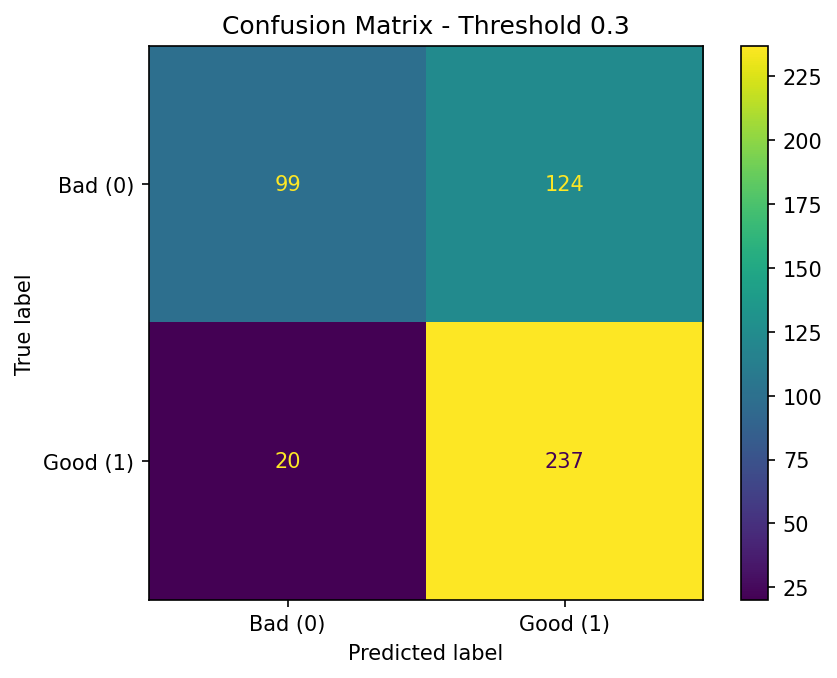


EVALUATION AT THRESHOLD: 0.5
Accuracy : 0.73125
Precision: 0.7519685039370079
Recall   : 0.7431906614785992
F1-Score : 0.7475538160469667


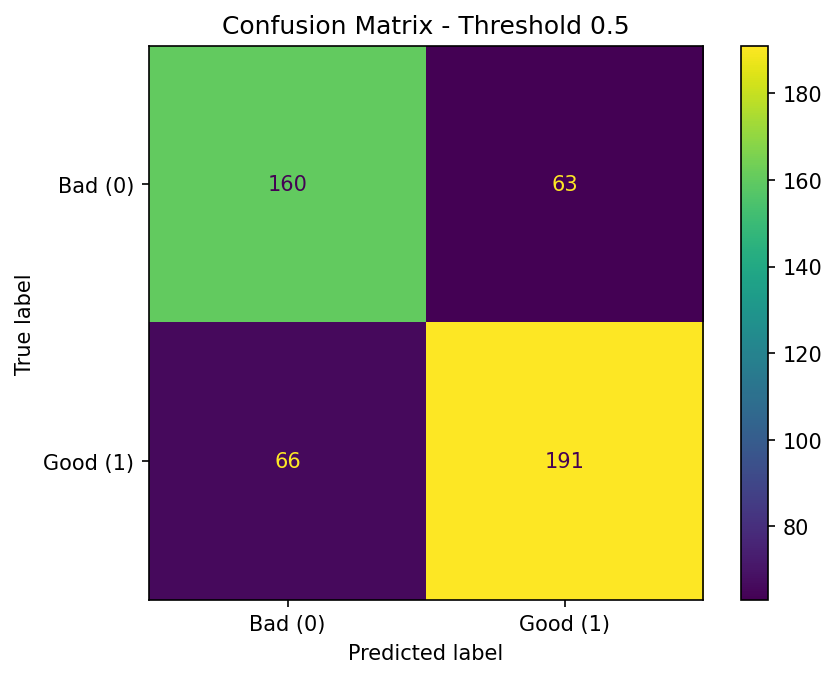


EVALUATION AT THRESHOLD: 0.7
Accuracy : 0.69375
Precision: 0.8525641025641025
Recall   : 0.5175097276264592
F1-Score : 0.6440677966101694


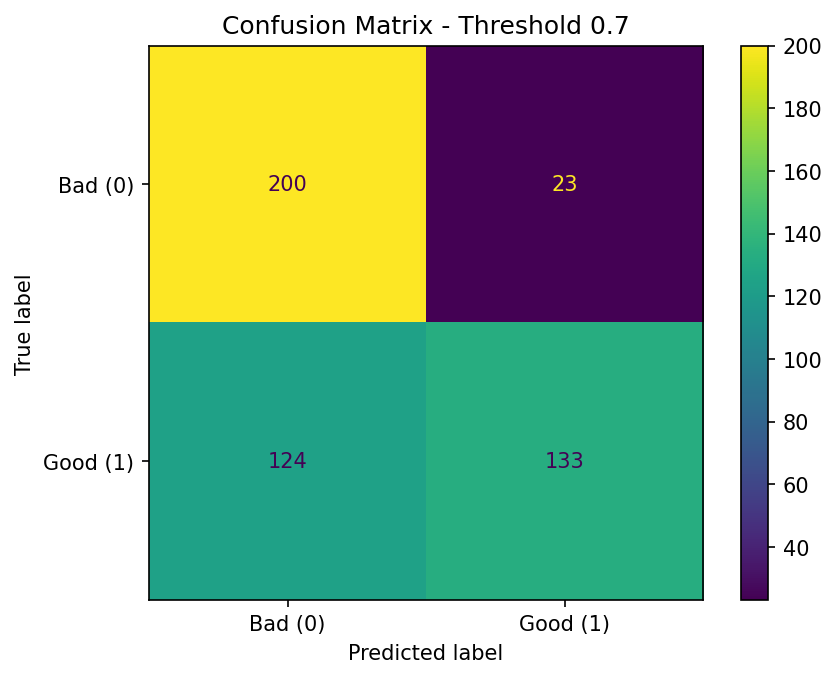

In [9]:
y_probs = pipeline.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.5, 0.7]

for thresh in thresholds:

    print(f"\n{'='*40}")
    print(f"EVALUATION AT THRESHOLD: {thresh}")
    print(f"{'='*40}")

    # Generate predictions using threshold
    y_pred_thresh = (y_probs >= thresh).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_thresh)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Bad (0)", "Good (1)"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - Threshold {thresh}")
    plt.show()